In [2]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical


In [3]:
x = np.load("/kaggle/input/pad-dataset/X_windows_full_ds.npy")
y_disease = np.load("/kaggle/input/pad-dataset/Y_disease_labels.npy")
y_activity = np.load("/kaggle/input/pad-dataset/Y_activity_labels.npy")

In [4]:
print("X shape:", x.shape)  
print("Disease labels shape:", y_disease.shape)
print("Activity labels shape:", y_activity.shape)

X shape: (484946, 100, 12)
Disease labels shape: (484946,)
Activity labels shape: (484946,)


In [5]:
X_train, X_temp, y_disease_train, y_disease_temp, y_activity_train, y_activity_temp = train_test_split(x, y_disease, y_activity, test_size=0.2, random_state=42, stratify = y_disease)
print("X_train shape:", X_train.shape)
print("y_disease_train shape:", y_disease_train.shape)
print("y_activity_train shape:", y_activity_train.shape)

X_train shape: (387956, 100, 12)
y_disease_train shape: (387956,)
y_activity_train shape: (387956,)


In [6]:
X_val, X_test, y_disease_val, y_disease_test, y_activity_val, y_activity_test = train_test_split(
    X_temp, y_disease_temp, y_activity_temp,
    test_size=0.5, 
    random_state=42,
    stratify=y_disease_temp
)

print("Train shapes:", X_train.shape, y_disease_train.shape, y_activity_train.shape)
print("Val shapes:", X_val.shape, y_disease_val.shape, y_activity_val.shape)
print("Test shapes:", X_test.shape, y_disease_test.shape, y_activity_test.shape)

Train shapes: (387956, 100, 12) (387956,) (387956,)
Val shapes: (48495, 100, 12) (48495,) (48495,)
Test shapes: (48495, 100, 12) (48495,) (48495,)


In [7]:
import pandas as pd
(unique, counts) = np.unique(y_disease_train, return_counts=True)
print(pd.DataFrame({'class': unique, 'count': counts}))

   class   count
0      0   65349
1      1  228307
2      2   94300


In [8]:
from sklearn.preprocessing import StandardScaler
N, T, F = X_train.shape
scaler = StandardScaler()
X_train_2d = X_train.reshape(-1, F)
X_val_2d   = X_val.reshape(-1, F)
X_test_2d  = X_test.reshape(-1, F)
scaler.fit(X_train_2d)
X_train_scaled = scaler.transform(X_train_2d).reshape(N, T, F)
X_val_scaled   = scaler.transform(X_val_2d).reshape(X_val.shape[0], T, F)
X_test_scaled  = scaler.transform(X_test_2d).reshape(X_test.shape[0], T, F)


In [9]:
if y_disease_train.ndim > 1:
    y_disease_train = np.argmax(y_disease_train, axis=1)

if y_disease_val.ndim > 1:
    y_disease_val = np.argmax(y_disease_val, axis=1)

In [32]:
print("disease train shape:", y_disease_train.shape)
print("disease val shape:", y_disease_val.shape)
print("Unique labels in train:", np.unique(y_disease_train[:20]))

disease train shape: (387956,)
disease val shape: (48495,)
Unique labels in train: [0 1 2]


In [11]:
from sklearn.utils.class_weight import compute_class_weight
disease_classes = np.unique(y_disease_train)
disease_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=disease_classes,
    y=y_disease_train
)

# Convert to dictionary: {class_index: weight}
disease_class_weights = {i: w for i, w in zip(disease_classes, disease_weights_array)}
print("Disease class weights:", disease_class_weights)


Disease class weights: {0: 1.9788928165184878, 1: 0.5664244489510469, 2: 1.3713538352774832}


In [12]:
print("y_disease_train shape:", y_disease_train.shape)
print("sample_weights[0] shape:", np.array([disease_class_weights[c] for c in y_disease_train]).shape)

print("y_activity_train shape:", y_activity_train.shape)
print("sample_weights[1] shape:", np.ones(len(y_activity_train)).shape)


y_disease_train shape: (387956,)
sample_weights[0] shape: (387956,)
y_activity_train shape: (387956,)
sample_weights[1] shape: (387956,)


In [13]:
import tensorflow as tf
class attention_layer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):   
        super().__init__(**kwargs)
    def build(self, input_shape):
        self.W=self.add_weight(name="att_weight", shape=(input_shape[-1],input_shape[-1]), initializer="glorot_uniform", trainable=True)
        self.b=self.add_weight(name="att_bias", shape=(input_shape[1],), initializer="zeros", trainable=True)
        self.v=self.add_weight(name="att_v", shape=(input_shape[-1],1), initializer="glorot_uniform", trainable=True)        
        super().build(input_shape)
    def call(self, inputs, mask=None):
        u = tf.tanh(tf.matmul(inputs,self.W)+self.b)
        scores = tf.matmul(u,self.v)
        alpha = tf.nn.softmax(scores, axis=1)
        context_vector = tf.reduce_sum(inputs*alpha, axis=1)
        return context_vector

In [14]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
from tensorflow.keras.regularizers import l2
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import Input, Dense, Conv1D, MaxPooling1D, LSTM, Dropout, Attention, Permute, Multiply, Lambda, Concatenate, GlobalAveragePooling1D, BatchNormalization

In [16]:
from sklearn.metrics import f1_score
from tensorflow.keras.callbacks import Callback

# Custom callback to compute F1 after each epoch
class F1ScoreCallback(Callback):
    def __init__(self, val_data, batch_size=32):
        super().__init__()
        self.validation_data = val_data
        self.batch_size = batch_size
        self.val_f1s = []

    def on_epoch_end(self, epoch, logs=None):
        X_val, y_val_dict = self.validation_data
        y_true = y_val_dict["disease_output"]

        # Get predictions
        y_pred = self.model.predict(X_val, batch_size=self.batch_size, verbose=0)
        y_pred_classes = np.argmax(y_pred[0], axis=1)  # [0] -> disease_output

        # Compute macro F1
        f1 = f1_score(y_true, y_pred_classes, average="macro")
        self.val_f1s.append(f1)

        print(f"\nEpoch {epoch+1}: val_macro_f1 = {f1:.4f}")
        logs["val_macro_f1"] = f1


In [18]:

def build_multi_task_model(timesteps=100, features=12, num_disease=3, num_activities=10, conv_filter=64, lstm_units=64, dropout_rate=0.3):
    input_layer = tf.keras.layers.Input(shape=(timesteps, features), name="inputs")

    #CNN
    x=layers.Conv1D(conv_filter, kernel_size=7, activation='relu',kernel_regularizer=l2(0.001), padding="valid")(input_layer)
    x=layers.BatchNormalization()(x)
    x=layers.Dropout(dropout_rate)(x)
    x=layers.Conv1D(conv_filter, kernel_size=5, activation='relu',kernel_regularizer=l2(0.001), padding="valid")(x)
    x=layers.BatchNormalization()(x)
    x=layers.MaxPooling1D(pool_size=2)(x)
    x=layers.Dropout(dropout_rate)(x)

    #BiLSTM
    x=layers.LSTM(lstm_units,kernel_regularizer=l2(0.001), return_sequences=True)(x)
    x=Dropout(0.3)(x)

    #Attention
    atten_out=attention_layer()(x)
    x=Dense(64, activation='relu', kernel_regularizer=l2(0.001))(atten_out)
    x=Dropout(0.3)(x)

    #Disease output
    disease_output = Dense(num_disease, activation='softmax', name='disease_output')(x)

    #Activity output
    activity_output = Dense(num_activities, activation='softmax', name='activity_output')(x)

    model=Model(inputs=input_layer, outputs=[disease_output, activity_output])
    return model

Unique values in y_disease_train: [1 2 5 6 7 8 9]
First 5 rows:
 [1 7 5 8 8]


In [22]:
input_shape = (X_train.shape[1], X_train.shape[2])
num_disease = len(np.unique(y_disease_train))
num_activities = len(np.unique(y_activity_train))

model = build_multi_task_model(timesteps=input_shape[0], features=input_shape[1], num_disease=num_disease, num_activities=num_activities)
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss={
        'disease_output': 'sparse_categorical_crossentropy',
        'activity_output': 'sparse_categorical_crossentropy'
    },
    metrics={
        "disease_output": ["accuracy", MacroF1(name="macro_f1")],
        'activity_output': 'accuracy'
    }
)

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint_path = "/content/checkpoints/epoch_{epoch:02d}_val_loss_{val_loss:.4f}.h5"

checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=False,   # save full model (set True if only weights needed)
    save_freq="epoch",         # save at every epoch
    monitor="val_loss",        # metric to monitor
    save_best_only=False,      # False → save all epochs
    verbose=1
)

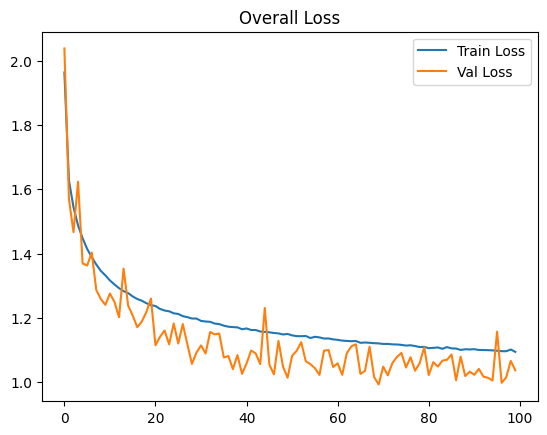

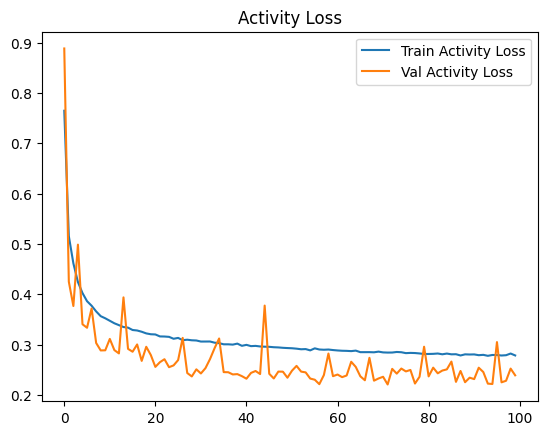

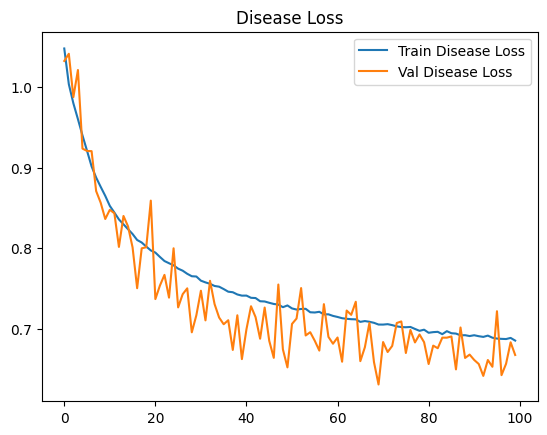

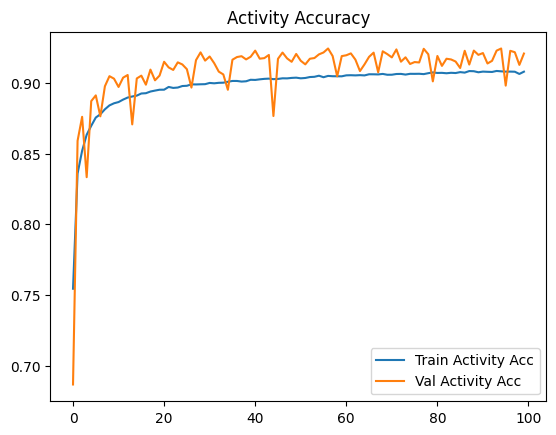

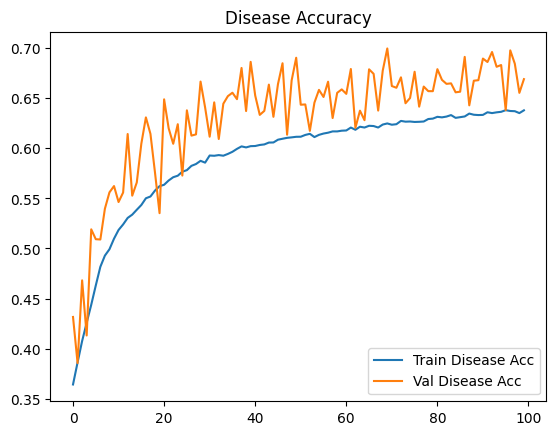

In [26]:
import matplotlib.pyplot as plt

# ---- Plot overall loss ----
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Overall Loss")
plt.show()

# ---- Plot activity loss ----
plt.plot(history.history["activity_output_loss"], label="Train Activity Loss")
plt.plot(history.history["val_activity_output_loss"], label="Val Activity Loss")
plt.legend()
plt.title("Activity Loss")
plt.show()

# ---- Plot disease loss ----
plt.plot(history.history["disease_output_loss"], label="Train Disease Loss")
plt.plot(history.history["val_disease_output_loss"], label="Val Disease Loss")
plt.legend()
plt.title("Disease Loss")
plt.show()

# ---- Plot activity accuracy ----
plt.plot(history.history["activity_output_accuracy"], label="Train Activity Acc")
plt.plot(history.history["val_activity_output_accuracy"], label="Val Activity Acc")
plt.legend()
plt.title("Activity Accuracy")
plt.show()

plt.plot(history.history["disease_output_accuracy"], label="Train Disease Acc")
plt.plot(history.history["val_disease_output_accuracy"], label="Val Disease Acc")
plt.legend()
plt.title("Disease Accuracy")
plt.show()

1516/1516 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step

Disease Classification Report:
              precision    recall  f1-score   support

   Disease_0     0.4452    0.9116    0.5983      8168
   Disease_1     0.8626    0.6240    0.7242     28539
   Disease_2     0.6630    0.6258    0.6439     11788

    accuracy                         0.6729     48495
   macro avg     0.6569    0.7205    0.6554     48495
weighted avg     0.7438    0.6729    0.6834     48495



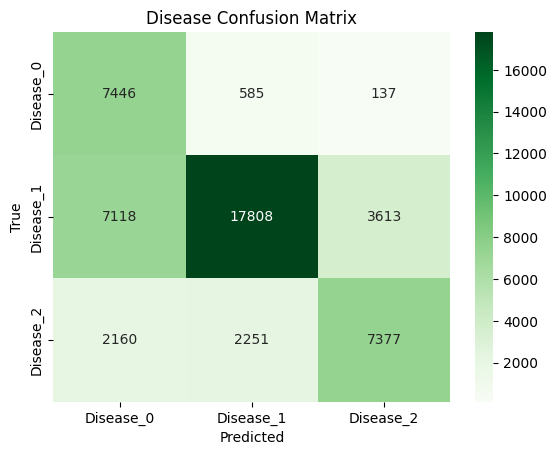


Activity Classification Report:
              precision    recall  f1-score   support

  Activity_0     0.7238    0.7179    0.7208      2967
  Activity_1     0.8629    0.9308    0.8956      3109
  Activity_2     0.9833    0.9870    0.9852     11843
  Activity_3     0.9816    0.8943    0.9359      3102
  Activity_4     0.7508    0.7835    0.7668      3118
  Activity_5     0.9697    0.9206    0.9445      3024
  Activity_6     0.9705    0.9968    0.9835     11941
  Activity_7     0.8016    0.8469    0.8236      3077
  Activity_8     0.8598    0.8081    0.8331      3111
  Activity_9     0.9866    0.8995    0.9410      3203

    accuracy                         0.9201     48495
   macro avg     0.8891    0.8785    0.8830     48495
weighted avg     0.9214    0.9201    0.9202     48495



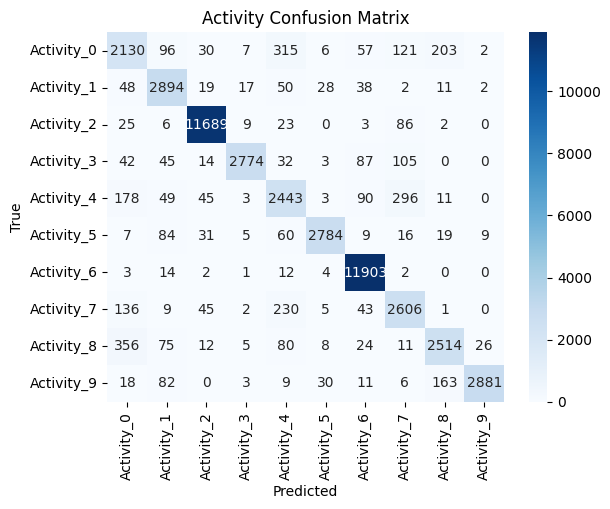

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ---- Predictions ----
y_pred_test = model.predict(X_test_scaled)

y_pred_disease = np.argmax(y_pred_test[0], axis=1)
y_pred_activity = np.argmax(y_pred_test[1], axis=1)

# ---- Disease Report ----
print("\nDisease Classification Report:")
print(classification_report(y_disease_test, y_pred_disease, target_names=[f"Disease_{i}" for i in range(3)], digits=4))

cm_disease = confusion_matrix(y_disease_test, y_pred_disease)
sns.heatmap(cm_disease, annot=True, fmt="d", cmap="Greens",
            xticklabels=[f"Disease_{i}" for i in range(3)],
            yticklabels=[f"Disease_{i}" for i in range(3)])
plt.title("Disease Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ---- Activity Report ----
print("\nActivity Classification Report:")
print(classification_report(y_activity_test, y_pred_activity, target_names=[f"Activity_{i}" for i in range(10)], digits=4))

cm_activity = confusion_matrix(y_activity_test, y_pred_activity)
sns.heatmap(cm_activity, annot=True, fmt="d", cmap="Blues",
            xticklabels=[f"Activity_{i}" for i in range(10)],
            yticklabels=[f"Activity_{i}" for i in range(10)])
plt.title("Activity Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
